<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 1</h3>
    <h5>Ejercicio 3 </h5>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistente: Sebastián Calcagno<p>
 <p>
</div>


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

En este ejercicio vamos a ver ejemplos de procesos autoregresivo de orden 1 AR(1)  y de orden 2 AR(2).

In [ ]:
np.random.seed(42)
n = 100
phi = 0.8
sigma = 1
c = 5

# Donde yt​=c + ϕ yt−1 ​ + ε

Si el proceso es estacionario, la serie oscilara a largo plazo a un valor, puntualmente en este ejercicio ( ¿porque , en este ejercicio podemos afirmar esto?)  :

arrancamos de esa ecuación X= c + ϕ X

In [ ]:
expected_value= c / (1 - phi)
print(f"La serie oscilara a largo plazo en {expected_value}")

La serie oscilara a largo plazo en 25.000000000000007


In [ ]:
# Aqui simulamos una serie temporal AR(1) con media 0 y cada valor depende del valor anterior y de un shock aleatorio. Sin constante



y_centered = np.zeros(n)
epsilon = np.random.normal(0, sigma, size=n)

for t in range(1, n):
    y_centered[t] = phi * y_centered[t-1] + epsilon[t]

In [ ]:
y_centered

array([ 0.        , -0.1382643 ,  0.5370771 ,  1.95269153,  1.32799985,
        0.82826293,  2.24182316,  2.56089325,  1.57924022,  1.80595222,
        0.98134408,  0.31934551,  0.49743868, -1.5153293 , -2.93718127,
       -2.91203255, -3.34245716, -2.35971839, -2.79579879, -3.64894273,
       -1.45350542, -1.38858064, -1.0433363 , -2.25941723, -2.35191651,
       -1.77061062, -2.56748207, -1.67828764, -1.9432688 , -1.84630879,
       -2.07875364,  0.18927527,  0.13792299, -0.94737254,  0.06464688,
       -1.16912614, -0.72643732, -2.54081998, -3.36084203, -2.49181239,
       -1.25498333, -0.83261838, -0.78174299, -0.92649809, -2.21972046,
       -2.49562058, -2.45713523, -0.90858596, -0.38325048, -2.06964054,
       -1.33162846, -1.45038505, -1.83723004, -0.85810774,  0.34451333,
        1.20689078,  0.1262951 , -0.20817629,  0.1647224 ,  1.10732304,
        0.4066842 ,  0.13968838, -0.99458427, -1.99187404, -0.78097341,
        0.7314613 ,  0.51315892,  1.41406003,  1.49288405,  0.54

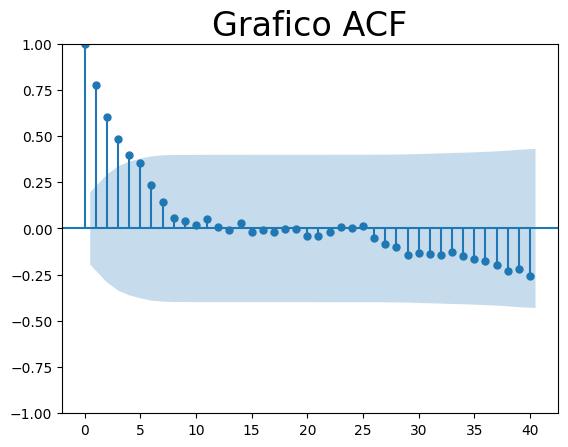

In [ ]:
# En este codigo vemos la funcion de autocorrelacion , donde damos una primera aproximacion a la estacionariedad de los datos

plot_acf(y_centered, lags=40)
plt.title("Grafico ACF", size= 24)
plt.show()

AR(1) con constante (evoluciona en torno a E[Y] = c / (1 - phi))

In [ ]:
# Ahora simulamos un AR(1) con constante. A diferencia del anteirio, ahora no estamos centrados en cero sino que tiene una media distinta.

# Vuelvan al comienzo de este codigo para ver las variables y tambien analicen las diferencias con la simulacion anterior

y_with_const = np.zeros(n)
for t in range(1, n):
    y_with_const[t] = c + phi * y_with_const[t-1] + epsilon[t]

In [ ]:
y_with_const

array([ 0.        ,  4.8617357 ,  9.5370771 , 14.15269153, 16.08799985,
       17.63626293, 20.68822316, 22.31801325, 22.38493622, 23.45050902,
       23.29698952, 23.17186186, 23.77945176, 22.11028117, 20.9633071 ,
       21.20835815, 20.9538554 , 22.07733165, 21.75384125, 20.9907693 ,
       23.25826421, 23.38083506, 23.77219626, 22.59300882, 22.53002433,
       23.13494205, 22.35696007, 23.26126607, 23.00837417, 23.11500558,
       22.89029785, 25.16451647, 25.11811595, 24.03678183, 25.05197038,
       23.82073265, 24.26544972, 22.45268965, 21.63396567, 22.50403377,
       23.7416936 , 24.16472316, 24.21613025, 24.0718005 , 22.77891841,
       22.50329052, 22.54199364, 24.09071714, 24.616192  , 22.92991345,
       23.66801473, 23.5493295 , 23.1625416 , 24.14170957, 25.34436718,
       26.20677386, 25.12620157, 24.79174888, 25.16466253, 26.10727515,
       25.40664588, 25.13965773, 24.00539121, 23.00810634, 24.2190109 ,
       25.73144875, 25.51314888, 26.414052  , 26.49287762, 25.54

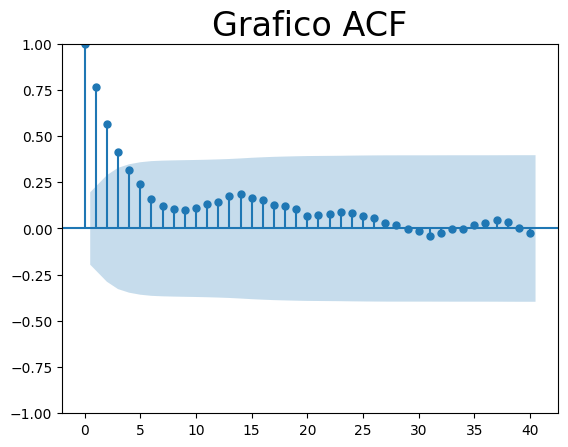

In [ ]:
# GRafico de autocorrelacion con constante, ¿ porque es similar al grafico anterior ?

plot_acf(y_with_const, lags=40)
plt.title("Grafico ACF", size= 24)
plt.show()

In [ ]:
expected_value= c / (1 - phi)

print(f"Valor esperado teorico", {expected_value})

Valor esperado teorico {25.000000000000007}


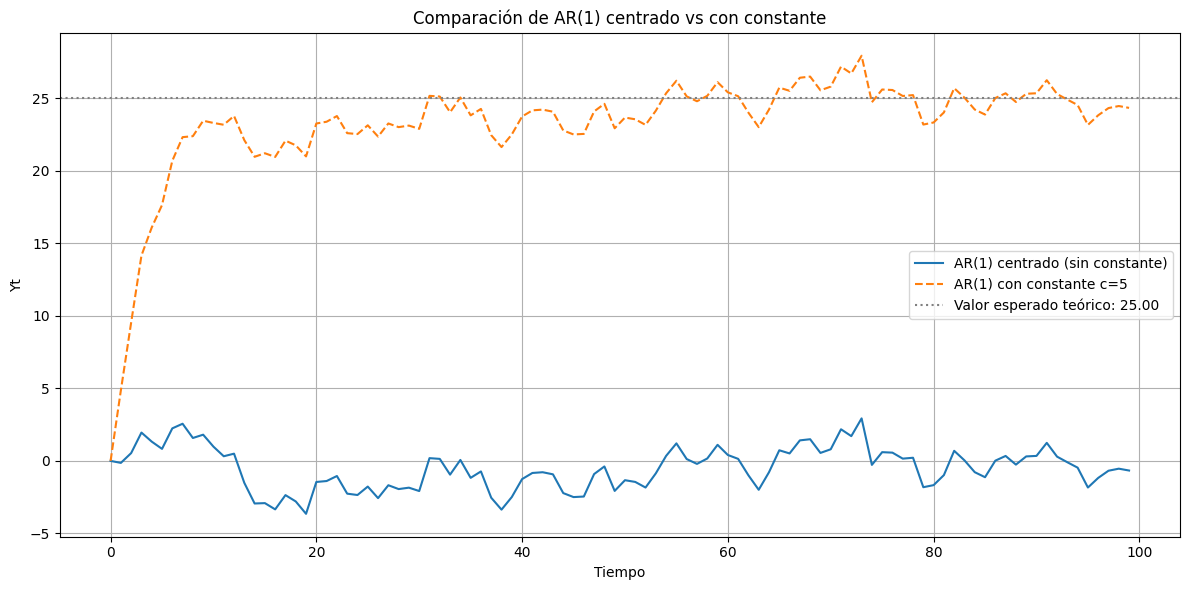

In [ ]:
# Aqui vemos visualmente lo comentado hasta ahora.

plt.figure(figsize=(12, 6))
plt.plot(y_centered, label='AR(1) centrado (sin constante)')
plt.plot(y_with_const, label=f'AR(1) con constante c={c}', linestyle='--')
plt.axhline(y=expected_value, color='gray', linestyle=':', label=f'Valor esperado teórico: {expected_value:.2f}')
plt.title('Comparación de AR(1) centrado vs con constante')
plt.xlabel('Tiempo')
plt.ylabel('Yt')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Proceso autoregresivo de orden dos sin constante y con constante

In [ ]:
np.random.seed(42)
n = 100
phi1 = 0.5
phi2 = -0.3
sigma = 1
c = 4

 AR(2) sin constante (centrado en 0)

In [ ]:
y_centered = np.zeros(n)
epsilon = np.random.normal(0, sigma, size=n)

for t in range(2, n):
    y_centered[t] = phi1 * y_centered[t-1] + phi2 * y_centered[t-2] + epsilon[t]

In [ ]:
y_centered

array([ 0.00000000e+00,  0.00000000e+00,  6.47688538e-01,  1.84687413e+00,
        4.94977127e-01, -5.40710631e-01,  1.16036436e+00,  1.50983010e+00,
       -6.26686448e-02,  5.82766914e-02, -4.15478754e-01, -6.90952138e-01,
        2.11298288e-02, -1.69542969e+00, -2.57897163e+00, -1.34314444e+00,
       -9.10711850e-01,  2.61834738e-01, -5.03893151e-01, -1.74280070e+00,
        7.45416365e-01,  6.69772092e-01,  1.78789341e-01, -1.53628514e+00,
       -1.36616210e+00, -1.11272917e-01, -7.96781406e-01,  1.06891902e-02,
       -3.56259673e-01, -4.73030343e-01, -7.31343882e-01,  1.62851535e+00,
        1.02016361e+00, -1.03618373e+00, -1.59603501e-03, -9.10786550e-01,
       -2.46050869e-01, -1.80945959e+00, -2.15910058e+00, -3.39851179e-01,
        1.21627117e+00,  8.81459218e-01, -3.98000233e-02, -5.85441473e-01,
       -1.75930272e+00, -1.42386313e+00, -6.44779518e-01,  1.16189141e+00,
        1.11799785e+00, -1.55260865e+00, -7.87619711e-01, -3.13109540e-01,
       -5.97190857e-01,  

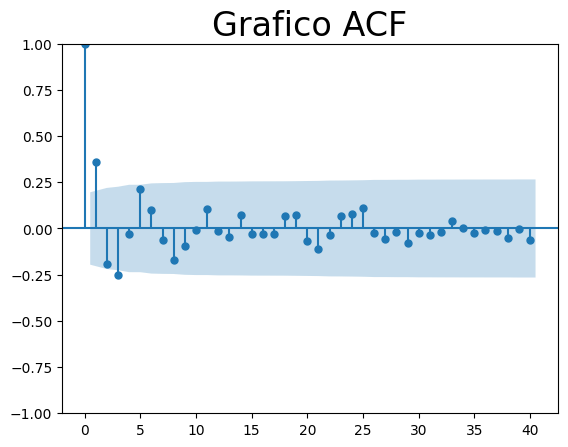

In [ ]:
plot_acf(y_centered, lags=40)
plt.title("Grafico ACF", size= 24)
plt.show()

AR(2) con constante

In [ ]:
y_const = np.zeros(n)

for t in range(2, n):
    y_const[t] = c + phi1 * y_const[t-1] + phi2 * y_const[t-2] + epsilon[t]



In [ ]:
y_const

array([0.        , 0.        , 4.64768854, 7.84687413, 6.29497713,
       4.55928937, 5.97036436, 6.3848301 , 4.93183136, 5.09302669,
       4.60354625, 4.30813536, 5.01496608, 3.30176219, 2.42147344,
       3.65792053, 4.08968712, 5.26171473, 4.49592716, 3.25714546,
       5.74544335, 5.66980174, 5.17879607, 3.46370933, 3.63383312,
       4.88872635, 4.20321966, 5.01068994, 4.64374038, 4.52696946,
       4.268656  , 6.62851535, 6.02016365, 3.96381629, 4.99840396,
       4.08921344, 4.75394913, 3.19054041, 2.84089942, 4.66014882,
       6.21627117, 5.88145922, 4.96019998, 4.41455853, 3.24069728,
       3.57613687, 4.35522048, 6.16189141, 6.11799785, 3.44739135,
       4.21238029, 4.68689046, 4.40280914, 5.40701372, 6.41366364,
       6.51600782, 4.4946873 , 3.98332893, 4.97452171, 6.2678073 ,
       5.1623729 , 4.51518528, 3.6025458 , 3.25051069, 5.35701743,
       7.05959554, 5.85068242, 5.81099545, 5.51192902, 4.36754612,
       4.89158996, 6.67356771, 5.83348083, 6.47931376, 2.86986

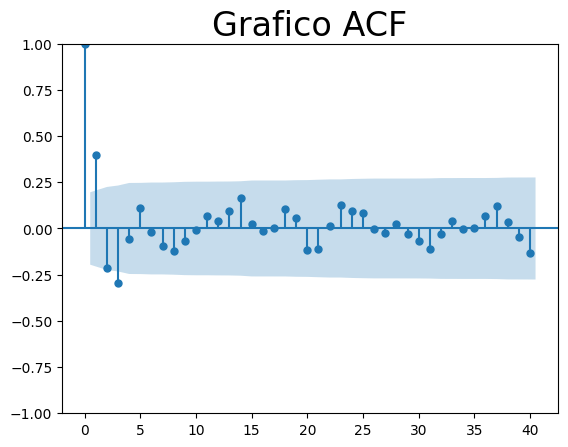

In [ ]:
# que pueden opinar de este grafico, ven diferencias con los graficos anteriores?


plot_acf(y_const, lags=40)
plt.title("Grafico ACF", size= 24)
plt.show()

In [ ]:
expected_value = c / (1 - phi1 - phi2)
print(f"Valor esperado teórico", {expected_value})

Valor esperado teórico {5.0}


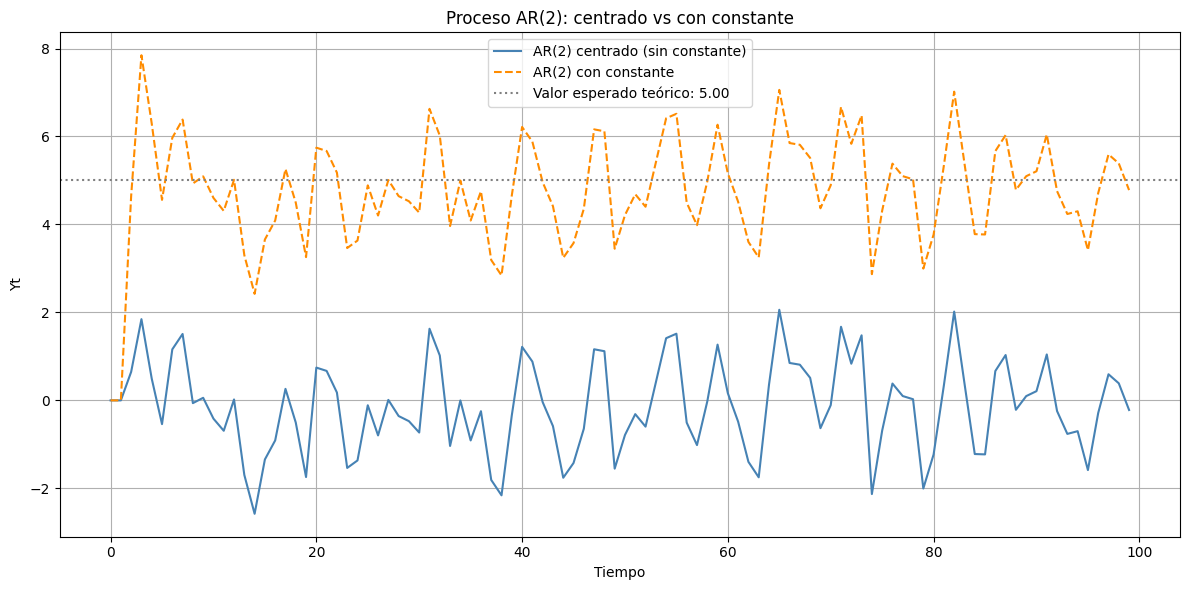

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_centered, label='AR(2) centrado (sin constante)', color='steelblue')
plt.plot(y_const, label='AR(2) con constante', linestyle='--', color='darkorange')
plt.axhline(expected_value, color='gray', linestyle=':', label=f'Valor esperado teórico: {expected_value:.2f}')
plt.title('Proceso AR(2): centrado vs con constante')
plt.xlabel('Tiempo')
plt.ylabel('Yt')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Nos gustaria, con este ejercicio "simple" que vean cuales son las diferencias, que pasa en cada caso y comparen todo lo visto y pensado con la teoria.

Cualquier comentario , pueden escribirnos por el grupo sin problemas.

Muchas gracias

FIN DEL EJERCICIO.